# Final Portfolio Assessment 2026 – Language Task
## True vs Fake News Classification with RNN, LSTM & GloVe-300 Embeddings

**Name:** Anush Acharya  
**Student ID:** 2406798  
**Module:** 6CS012 – Artificial Intelligence and Machine Learning


## GPU Setup & Core Imports
Configures the RTX 4050 via DirectML (TF 2.10). CUDA DLL paths are prepended before TensorFlow loads.

In [1]:
import os
import sys
import re
import time
import warnings
import logging
import subprocess
warnings.filterwarnings('ignore')

# Prepend CUDA 11 DLL directories so TF 2.10 can find them
_nvidia_base = os.path.normpath(
    os.path.join(os.path.dirname(sys.executable),
                 '..', 'Lib', 'site-packages', 'nvidia'))
_cuda_paths = [
    os.path.join(_nvidia_base, pkg, 'bin')
    for pkg in ['cuda_runtime', 'cublas', 'cudnn', 'cufft',
                'curand', 'cusolver', 'cusparse', 'cuda_nvrtc']
    if os.path.isdir(os.path.join(_nvidia_base, pkg, 'bin'))
]
os.environ['PATH'] = os.pathsep.join(_cuda_paths) + os.pathsep + os.environ.get('PATH', '')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout,
    Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import nltk
for _pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(_pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix, accuracy_score)

print('All imports successful.')
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')


All imports successful.
TensorFlow : 2.10.0
NumPy      : 1.26.4


### GPU Verification
Enables memory growth on the RTX 4050 so DirectML allocates only what is needed.

In [2]:
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU devices detected: {len(gpus)}')
for i, g in enumerate(gpus):
    print(f'  GPU:{i} -> {g}')

for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print(f'  set_memory_growth skipped: {e}')

if gpus:
    print('Memory growth enabled on all GPU devices.')
else:
    print('No GPU detected – running on CPU.')

GPU devices detected: 1
  GPU:0 -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Memory growth enabled on all GPU devices.


## Section 4.5.1 – Text Preprocessing, Tokenization and Sequence Padding

**Requirements:**
- Load dataset with Pandas
- Clean text: lowercase · remove URLs/mentions/hashtags/numbers/special chars · handle contractions · remove stopwords · lemmatize
- Visualise cleaned data (word cloud + most-frequent words)
- 80/20 train-test split
- Keras Tokenizer → integer sequences
- Percentile-based padding

### Load Dataset

In [3]:
DATASET_PATH = r'D:\semester6\AI\AI Assesment\text classification\10.True vs. Fake News Dataset\truevsfakenews.csv'

df = pd.read_csv(DATASET_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nNull values:')
print(df.isnull().sum())
df.head()

Dataset shape : (20000, 2)
Columns       : ['text', 'label']

Label distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Null values:
text     0
label    0
dtype: int64


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


### Class Distribution

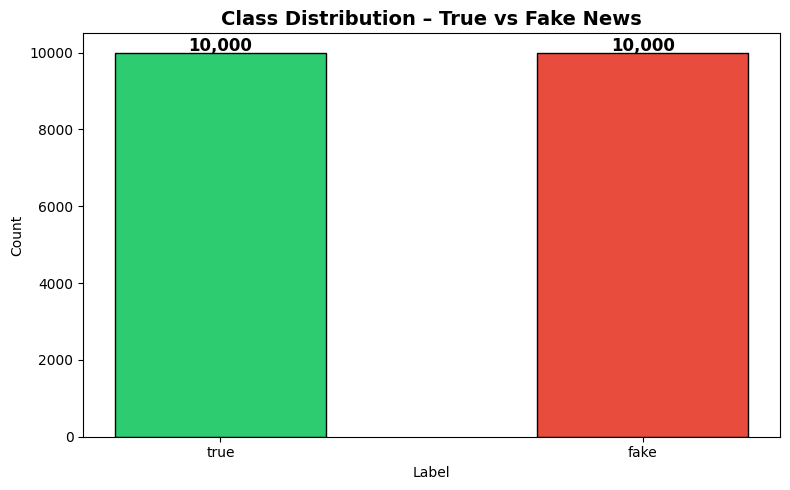

True news : 10,000
Fake news : 10,000


In [4]:
counts = df['label'].value_counts()
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')
plt.title('Class Distribution – True vs Fake News', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f'True news : {counts.get("true", 0):,}')
print(f'Fake news : {counts.get("fake", 0):,}')

### Text Length Analysis
Understanding sequence length distribution helps choose an appropriate padding length.

Word-count statistics per class:
         count   mean    std  min    25%    50%    75%     max
label                                                         
fake   10000.0  445.9  191.0  1.0  340.0  408.0  510.0  7033.0
true   10000.0  406.3  289.1  0.0  142.0  384.0  572.0  5172.0


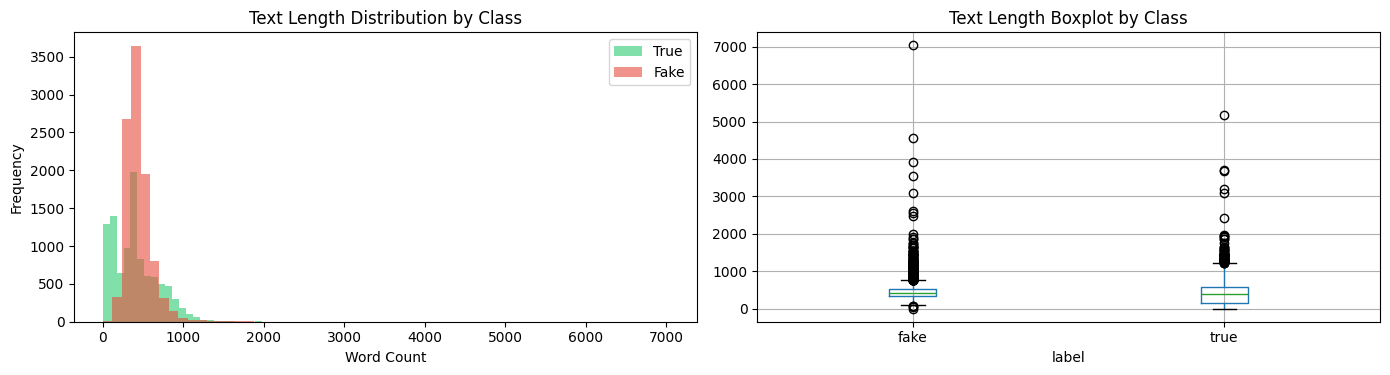

In [5]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print('Word-count statistics per class:')
print(df.groupby('label')['text_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, color in zip(['true', 'fake'], ['#2ecc71', '#e74c3c']):
    axes[0].hist(df[df['label'] == label]['text_length'],
                 bins=60, alpha=0.6, label=label.capitalize(), color=color)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution by Class')
axes[0].legend()
df.boxplot(column='text_length', by='label', ax=axes[1])
axes[1].set_title('Text Length Boxplot by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()

### Text Cleaning Function
Applies all required preprocessing:
- Lowercase · contraction expansion · remove URLs / emails / mentions / hashtags / numbers / punctuation
- Stopword removal · lemmatization · tokens shorter than 3 chars removed

In [6]:
CONTRACTIONS = {
    "don't":"do not",   "can't":"cannot",       "won't":"will not",
    "isn't":"is not",   "aren't":"are not",     "wasn't":"was not",
    "weren't":"were not","hasn't":"has not",     "haven't":"have not",
    "hadn't":"had not", "doesn't":"does not",   "didn't":"did not",
    "wouldn't":"would not","couldn't":"could not","shouldn't":"should not",
    "i'm":"i am",       "i've":"i have",        "i'll":"i will",
    "i'd":"i would",    "it's":"it is",         "that's":"that is",
    "there's":"there is","they're":"they are",  "we're":"we are",
    "you're":"you are", "he's":"he is",         "she's":"she is",
    "let's":"let us",   "what's":"what is",     "who's":"who is",
    "where's":"where is","here's":"here is",    "we've":"we have",
    "you've":"you have","they've":"they have",  "we'd":"we would",
    "you'd":"you would","they'd":"they would",  "we'll":"we will",
    "you'll":"you will","they'll":"they will",
}

STOP_WORDS = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print('clean_text() defined.')
sample = "Don't believe the FAKE news at https://example.com! #Politics @user 123"
print(f'  Input  : {sample}')
print(f'  Output : {clean_text(sample)}')

clean_text() defined.
  Input  : Don't believe the FAKE news at https://example.com! #Politics @user 123
  Output : believe fake news


### Apply Text Cleaning to Full Dataset

In [7]:
print('Cleaning all articles (this takes ~1-2 minutes)...')
t0 = time.time()
df['cleaned_text'] = df['text'].apply(clean_text)
print(f'Done in {time.time()-t0:.1f}s')

df = df[df['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'\nRows after empty-text removal: {len(df):,}')

print('\nSample cleaned texts:')
for i in range(3):
    orig    = str(df['text'].iloc[i])[:120].replace('\n', ' ')
    cleaned = df['cleaned_text'].iloc[i][:120]
    label   = df['label'].iloc[i]
    print(f'  [{label}]')
    print(f'    Original : {orig}...')
    print(f'    Cleaned  : {cleaned}...')

Cleaning all articles (this takes ~1-2 minutes)...
Done in 16.4s

Rows after empty-text removal: 19,998

Sample cleaned texts:
  [true]
    Original : WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Committee blasted the ...
    Cleaned  : washington reuters republican democratic leader senate foreign relation committee blasted state department tuesday cut s...
  [fake]
    Original : Women should get as far away from Oklahoma as soon as possible because Christian Sharia law is about to make their lives...
    Cleaned  : woman get far away oklahoma soon possible christian sharia law make life living hellif oklahoma state gop rep george fau...
  [fake]
    Original : Another huge crowd of Americans tuned in last week as the Republicans held their latest fear-fest, also known as a debat...
    Cleaned  : another huge crowd american tuned last week republican held latest fearfest also known debate refusing acknowledge many ...


### Word Cloud Visualisation

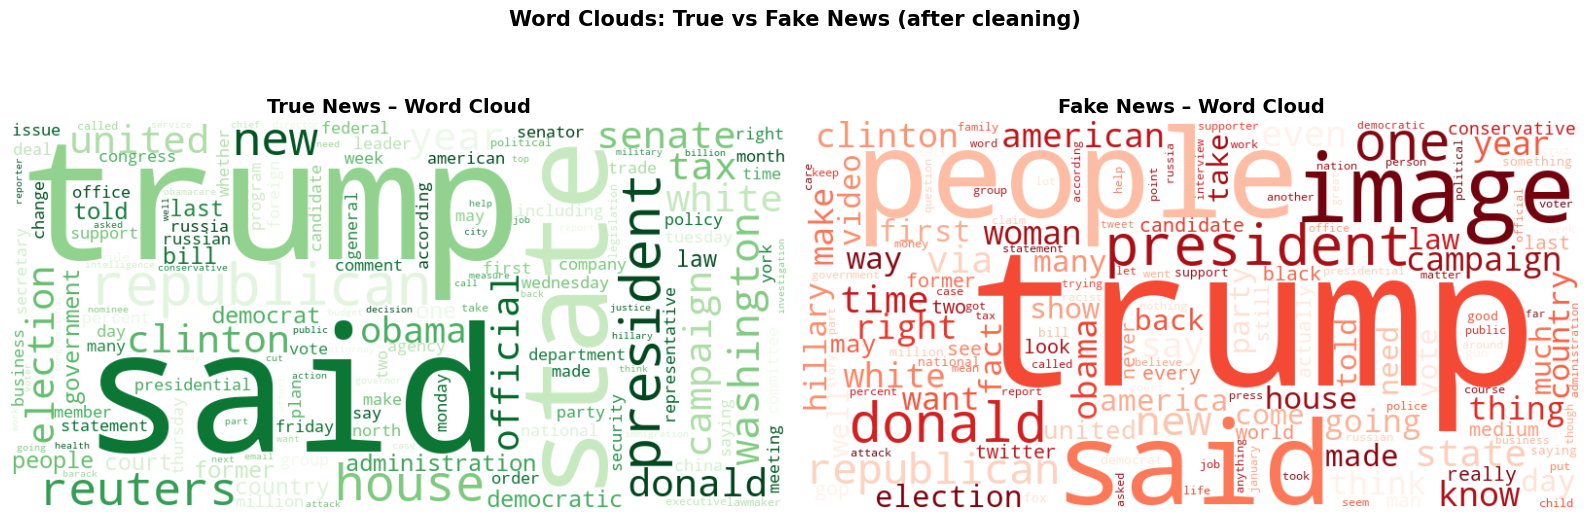

In [8]:
import subprocess
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, cmap, title in zip(
    axes,
    ['true', 'fake'],
    ['Greens', 'Reds'],
    ['True News – Word Cloud', 'Fake News – Word Cloud']
):
    combined = ' '.join(df[df['label'] == label]['cleaned_text'].dropna())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=150, collocations=False).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle('Word Clouds: True vs Fake News (after cleaning)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Top-20 Most Frequent Words per Class

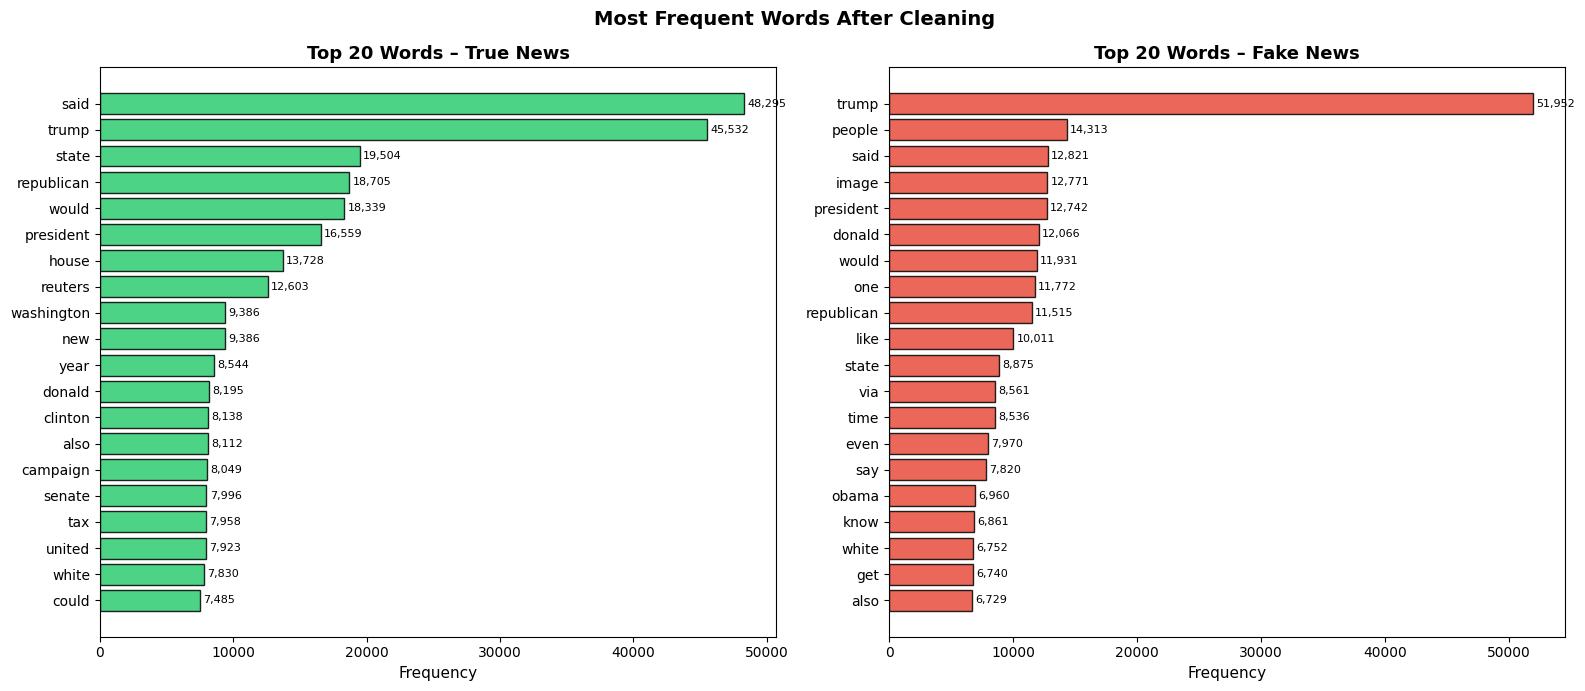

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, label, color in zip(axes, ['true', 'fake'], ['#2ecc71', '#e74c3c']):
    all_words = ' '.join(df[df['label'] == label]['cleaned_text'].dropna()).split()
    word_freq = Counter(all_words).most_common(20)
    words, counts = zip(*word_freq)
    bars = ax.barh(range(len(words)), counts, color=color, alpha=0.85, edgecolor='black')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(f'Top 20 Words – {label.capitalize()} News', fontsize=13, fontweight='bold')
    max_c = max(counts)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + 0.005*max_c, bar.get_y()+bar.get_height()/2,
                f'{cnt:,}', va='center', fontsize=8)
plt.suptitle('Most Frequent Words After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Label Encoding & 80/20 Train-Test Split
- **true** → 1 · **fake** → 0
- Stratified split preserves class ratios in both sets

In [10]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df['cleaned_text'].tolist()
y = df['label_enc'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Train distribution: {Counter(y_train)}')
print(f'Test  distribution: {Counter(y_test)}')

Label mapping: {'fake': 0, 'true': 1}

Training samples : 15,998
Test samples     : 4,000
Train distribution: Counter({1: 7999, 0: 7999})
Test  distribution: Counter({1: 2000, 0: 2000})


### Tokenisation with Keras Tokenizer
Fits **only on training data** to prevent data leakage.

In [11]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab = len(tokenizer.word_index)
print(f'Total unique words seen : {actual_vocab:,}')
print(f'Vocabulary capped at    : {VOCAB_SIZE:,}')

oov_idx   = tokenizer.word_index.get('<OOV>', 1)
total_tok = sum(len(s) for s in X_test_seq)
oov_count = sum(s.count(oov_idx) for s in X_test_seq)
print(f'\nOOV rate on test set: {oov_count/total_tok*100:.2f}% ({oov_count:,}/{total_tok:,} tokens)')

Total unique words seen : 104,522
Vocabulary capped at    : 20,000

OOV rate on test set: 4.06% (38,295/942,853 tokens)


### Percentile-Based Padding
Uses the **95th percentile** of training lengths, capped at 500 tokens.

In [12]:
seq_lengths = [len(s) for s in X_train_seq]
print('Sequence length percentiles (training set):')
for p in [50, 75, 90, 95, 99, 100]:
    print(f'  {p:>3}th percentile : {int(np.percentile(seq_lengths, p)):>6} tokens')

MAX_LEN = min(int(np.percentile(seq_lengths, 95)), 500)
print(f'\nSelected MAX_LEN : {MAX_LEN} tokens (95th pct, hard-cap 500)')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print(f'\nX_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad  shape : {X_test_pad.shape}')

Sequence length percentiles (training set):
   50th percentile :    218 tokens
   75th percentile :    285 tokens
   90th percentile :    406 tokens
   95th percentile :    487 tokens
   99th percentile :    645 tokens
  100th percentile :   4466 tokens

Selected MAX_LEN : 487 tokens (95th pct, hard-cap 500)

X_train_pad shape : (15998, 487)
X_test_pad  shape : (4000, 487)


## Section 4.5.2 – Model Building



### Shared Model Parameters

In [13]:
vocab_size    = VOCAB_SIZE + 1   # +1 for <OOV>/padding index
embedding_dim = 128              # trainable embedding dimension
hidden_units  = 64               # RNN/LSTM hidden units

print('Shared hyper-parameters:')
print(f'  vocab_size    : {vocab_size:,}')
print(f'  embedding_dim : {embedding_dim}')
print(f'  hidden_units  : {hidden_units}')
print(f'  MAX_LEN       : {MAX_LEN}')

Shared hyper-parameters:
  vocab_size    : 20,001
  embedding_dim : 128
  hidden_units  : 64
  MAX_LEN       : 487


### Model 1 – Simple RNN with Trainable Embedding

In [14]:
print('=' * 60)
print('MODEL 1 : Simple RNN  +  Trainable Embedding')
print('=' * 60)

model_rnn = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=MAX_LEN),
    SimpleRNN(units=hidden_units, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='model1_simple_rnn')

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_rnn.summary()

MODEL 1 : Simple RNN  +  Trainable Embedding
Model: "model1_simple_rnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 487, 128)          2560128   
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                12352     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,574,593
Trainable params: 2,574,593
Non-trainable params: 0
____________________________________________________________

### Model 2 – LSTM with Trainable Embedding

In [15]:
print('=' * 60)
print('MODEL 2 : LSTM  +  Trainable Embedding')
print('=' * 60)

model_lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=MAX_LEN),
    LSTM(units=hidden_units, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='model2_lstm_trainable')

model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
model_lstm.summary()

MODEL 2 : LSTM  +  Trainable Embedding
Model: "model2_lstm_trainable"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 487, 128)          2560128   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,611,649
Trainable params: 2,611,649
Non-trainable params: 0
______________________________________________________________

### Load Pretrained GloVe-300 Embeddings
Uses `glove-wiki-gigaword-300` (300-dim, ~376 MB) via Gensim downloader.
Downloads once, then uses the local cache on subsequent runs.

In [16]:
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'gensim'],
                       capture_output=True, text=True)
if 'gensim' not in result.stdout:
    print('Installing gensim...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])

import gensim.downloader as api

GLOVE_KEY           = 'glove-wiki-gigaword-300'
EMBEDDING_DIM_GLOVE = 300

print(f"Loading '{GLOVE_KEY}' (downloads ~376 MB on first run)...")
t0 = time.time()
glove_model = api.load(GLOVE_KEY)
print(f'Loaded in {time.time()-t0:.1f}s  |  '
      f'vocab: {len(glove_model):,}  |  dim: {glove_model.vector_size}')

Loading 'glove-wiki-gigaword-300' (downloads ~376 MB on first run)...
Loaded in 67.7s  |  vocab: 400,000  |  dim: 300


### Build GloVe-300 Embedding Matrix

In [17]:
vocab_size_glove = vocab_size
embedding_matrix = np.zeros((vocab_size_glove, EMBEDDING_DIM_GLOVE))

hit = miss = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size_glove:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hit += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM_GLOVE,))
        miss += 1

print(f'Words found in GloVe-300    : {hit:,}  ({hit/(hit+miss)*100:.1f}%)')
print(f'Words not found (random init): {miss:,} ({miss/(hit+miss)*100:.1f}%)')
print(f'Embedding matrix shape       : {embedding_matrix.shape}')

import gc
del glove_model
gc.collect()
print('\nGloVe model freed from RAM.')

Words found in GloVe-300    : 18,309  (91.5%)
Words not found (random init): 1,691 (8.5%)
Embedding matrix shape       : (20001, 300)

GloVe model freed from RAM.


### Model 3 – LSTM with Pretrained GloVe-300 (frozen)
The embedding layer is frozen (`trainable=False`) to preserve pretrained weights.
`compile()` and `set_weights()` are called here in Section 4.5.2 (matching the
original notebook pattern). Models 4 and 5 are built immediately before their
training in Section 4.5.3 to avoid DirectML graph conflicts that would crash
SimpleRNN's CPU fallback.

In [18]:
print('=' * 60)
print('MODEL 3 : LSTM  +  Pretrained GloVe-300 (frozen)')
print('=' * 60)

model_lstm_glove = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size_glove,
              output_dim=EMBEDDING_DIM_GLOVE,
              input_length=MAX_LEN,
              trainable=False),
    LSTM(units=128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='model3_lstm_glove300')

model_lstm_glove.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

emb3 = next(l for l in model_lstm_glove.layers
            if isinstance(l, tf.keras.layers.Embedding))
emb3.set_weights([embedding_matrix])
print('GloVe-300 weights loaded.')
model_lstm_glove.summary()


MODEL 3 : LSTM  +  Pretrained GloVe-300 (frozen)
GloVe-300 weights loaded.
Model: "model3_lstm_glove300"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 487, 300)          6000300   
                                                                 
 lstm_1 (LSTM)               (None, 128)               219648    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 6,228,269
Trainable params: 227,969
Non-trainable params: 6,000,300
_____________________

### Model 4 – Bidirectional LSTM + GloVe-300 (frozen)
`Bidirectional` wraps the LSTM to process sequences both left→right and right→left,
doubling the hidden state to 256-dim and capturing richer context.

In [19]:
print('MODEL 4 architecture preview (built & trained in Section 4.5.3)')
print('=' * 60)
print(' Layer                    Output Shape        Param #')
print(' ──────────────────────────────────────────────────────')
print(f' Embedding (frozen)       (None,{MAX_LEN},300)  {vocab_size_glove*300:>9,}')
print(f' Bidirectional(LSTM 128)  (None, 256)            {4*(300+128+1)*128*2:>9,}')
print(f' Dropout(0.3)             (None, 256)                    0')
print(f' Dense(64, relu)          (None, 64)             {256*64+64:>9,}')
print(f' Dense(1, sigmoid)        (None,  1)             {64*1+1:>9,}')
print(' ──────────────────────────────────────────────────────')
print(' Architecture: GloVe-300 frozen → BiLSTM(128) → Dense → output')
print(' Built and compiled immediately before training in Section 4.5.3.')


MODEL 4 architecture preview (built & trained in Section 4.5.3)
 Layer                    Output Shape        Param #
 ──────────────────────────────────────────────────────
 Embedding (frozen)       (None,487,300)  6,000,300
 Bidirectional(LSTM 128)  (None, 256)              439,296
 Dropout(0.3)             (None, 256)                    0
 Dense(64, relu)          (None, 64)                16,448
 Dense(1, sigmoid)        (None,  1)                    65
 ──────────────────────────────────────────────────────
 Architecture: GloVe-300 frozen → BiLSTM(128) → Dense → output
 Built and compiled immediately before training in Section 4.5.3.


### Model 5 – BiLSTM + Bahdanau Attention + GloVe-300 (frozen)
`return_sequences=True` passes the full token sequence to the attention layer.
Attention computes a score per token (Dense tanh), normalises with softmax, then
forms a weighted sum of BiLSTM states as the context vector.

In [20]:
print('MODEL 5 architecture preview (built & trained in Section 4.5.3)')
print('=' * 60)
print(' Layer                       Output Shape           Param #')
print(' ─────────────────────────────────────────────────────────────')
print(f' Embedding (frozen)          (None,{MAX_LEN},300)     {vocab_size_glove*300:>9,}')
print(f' Bidirectional(LSTM 128,     (None,{MAX_LEN},256)     {4*(300+128+1)*128*2:>9,}')
print(f'   return_sequences=True)')
print(f' Dropout(0.3)                (None,{MAX_LEN},256)             0')
print(f' BahdanauAttention           (None, 256)              {256*1+1:>9,}')
print(f' Dense(128, relu)            (None, 128)              {256*128+128:>9,}')
print(f' Dropout(0.4)')
print(f' Dense(64, relu)             (None,  64)              {128*64+64:>9,}')
print(f' Dense(1, sigmoid)           (None,   1)              {64+1:>9,}')
print(' ─────────────────────────────────────────────────────────────')
print(' Architecture: GloVe-300 frozen → BiLSTM(return_sequences=True)')
print('               → BahdanauAttention → Dense(128) → Dense(64) → output')
print(' Built and compiled immediately before training in Section 4.5.3.')

# Define the custom layer class here so it is in scope for Section 4.5.3.
class BahdanauAttention(tf.keras.layers.Layer):
    """Bahdanau-style soft attention — custom Layer (not Lambda) for DirectML/TF 2.10."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score_dense = Dense(1, activation='tanh')

    def call(self, x):
        score   = self.score_dense(x)                  # (batch, seq_len, 1)
        weights = tf.nn.softmax(score, axis=1)         # (batch, seq_len, 1)
        context = tf.reduce_sum(x * weights, axis=1)  # (batch, features)
        return context

    def get_config(self):
        return super().get_config()

print('\nBahdanauAttention class defined (used when Model 5 is built in 4.5.3).')


MODEL 5 architecture preview (built & trained in Section 4.5.3)
 Layer                       Output Shape           Param #
 ─────────────────────────────────────────────────────────────
 Embedding (frozen)          (None,487,300)     6,000,300
 Bidirectional(LSTM 128,     (None,487,256)       439,296
   return_sequences=True)
 Dropout(0.3)                (None,487,256)             0
 BahdanauAttention           (None, 256)                    257
 Dense(128, relu)            (None, 128)                 32,896
 Dropout(0.4)
 Dense(64, relu)             (None,  64)                  8,256
 Dense(1, sigmoid)           (None,   1)                     65
 ─────────────────────────────────────────────────────────────
 Architecture: GloVe-300 frozen → BiLSTM(return_sequences=True)
               → BahdanauAttention → Dense(128) → Dense(64) → output
 Built and compiled immediately before training in Section 4.5.3.

BahdanauAttention class defined (used when Model 5 is built in 4.5.3).


## Section 4.5.3 – Model Training, Evaluation and Comparison

Each model is trained with:
- **EarlyStopping** (`patience=3`, monitors `val_loss`, restores best weights)
- **ModelCheckpoint** (saves best epoch by `val_accuracy`)
- Up to **10 epochs**, `batch_size=256`

### Train Model 1 – Simple RNN

In [21]:
print('Training MODEL 1 : Simple RNN')
print('-' * 50)

es1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
ck1 = ModelCheckpoint('model1_rnn_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)

t0 = time.time()
history_rnn = model_rnn.fit(
    X_train_pad, y_train_arr,
    validation_data=(X_test_pad, y_test_arr),
    epochs=10, batch_size=256,
    callbacks=[es1, ck1], verbose=1
)
rnn_time = time.time() - t0
print(f'\nRNN training done in {rnn_time:.1f}s  ({len(history_rnn.history["loss"])} epochs)')


Training MODEL 1 : Simple RNN
--------------------------------------------------
Epoch 1/10
63/63 [==============================] - 18s 264ms/step - loss: 0.6842 - accuracy: 0.5326 - val_loss: 0.6757 - val_accuracy: 0.5518
Epoch 2/10
63/63 [==============================] - 16s 249ms/step - loss: 0.6775 - accuracy: 0.5336 - val_loss: 0.6760 - val_accuracy: 0.5393
Epoch 3/10
63/63 [==============================] - 16s 250ms/step - loss: 0.6659 - accuracy: 0.5347 - val_loss: 0.6750 - val_accuracy: 0.5408
Epoch 4/10
63/63 [==============================] - 16s 250ms/step - loss: 0.6611 - accuracy: 0.5409 - val_loss: 0.6755 - val_accuracy: 0.4983
Epoch 5/10
63/63 [==============================] - 15s 244ms/step - loss: 0.6868 - accuracy: 0.5384 - val_loss: 0.6938 - val_accuracy: 0.4988
Epoch 6/10
63/63 [==============================] - 16s 252ms/step - loss: 0.6751 - accuracy: 0.5341 - val_loss: 0.6641 - val_accuracy: 0.6068
Epoch 7/10
63/63 [==============================] - 16s 259ms

### Train Model 2 – LSTM (trainable embedding)

In [22]:
print('Training MODEL 2 : LSTM')
print('-' * 50)

es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
ck2 = ModelCheckpoint('model2_lstm_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)

t0 = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train_arr,
    validation_data=(X_test_pad, y_test_arr),
    epochs=10, batch_size=256,
    callbacks=[es2, ck2], verbose=1
)
lstm_time = time.time() - t0
print(f'\nLSTM training done in {lstm_time:.1f}s  ({len(history_lstm.history["loss"])} epochs)')


Training MODEL 2 : LSTM
--------------------------------------------------
Epoch 1/10
63/63 [==============================] - 4s 39ms/step - loss: 0.6919 - accuracy: 0.5318 - val_loss: 0.6799 - val_accuracy: 0.5385
Epoch 2/10
63/63 [==============================] - 2s 34ms/step - loss: 0.6744 - accuracy: 0.5365 - val_loss: 0.6701 - val_accuracy: 0.5443
Epoch 3/10
63/63 [==============================] - 2s 34ms/step - loss: 0.6650 - accuracy: 0.5443 - val_loss: 0.6682 - val_accuracy: 0.5495
Epoch 4/10
63/63 [==============================] - 2s 35ms/step - loss: 0.6578 - accuracy: 0.5543 - val_loss: 0.6615 - val_accuracy: 0.5543
Epoch 5/10
63/63 [==============================] - 2s 33ms/step - loss: 0.6812 - accuracy: 0.5596 - val_loss: 0.6665 - val_accuracy: 0.5505
Epoch 6/10
63/63 [==============================] - 2s 34ms/step - loss: 0.6544 - accuracy: 0.5673 - val_loss: 0.6668 - val_accuracy: 0.5483
Epoch 7/10
63/63 [==============================] - 2s 34ms/step - loss: 0.7581

### Train Model 3 – LSTM + GloVe-300

In [23]:
print('Training MODEL 3 : LSTM + GloVe-300')
print('-' * 50)

es3 = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True, verbose=1)
ck3 = ModelCheckpoint('model3_lstm_glove_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)

t0 = time.time()
history_glove = model_lstm_glove.fit(
    X_train_pad, y_train_arr,
    validation_data=(X_test_pad, y_test_arr),
    epochs=10, batch_size=256,
    callbacks=[es3, ck3], verbose=1
)
glove_time = time.time() - t0
print(f'\nLSTM+GloVe-300 done in {glove_time:.1f}s  ({len(history_glove.history["loss"])} epochs)')


Training MODEL 3 : LSTM + GloVe-300
--------------------------------------------------
Epoch 1/10
63/63 [==============================] - 4s 54ms/step - loss: 0.6771 - accuracy: 0.5457 - val_loss: 0.6698 - val_accuracy: 0.5525
Epoch 2/10
63/63 [==============================] - 3s 50ms/step - loss: 0.6153 - accuracy: 0.6479 - val_loss: 0.3470 - val_accuracy: 0.9193
Epoch 3/10
63/63 [==============================] - 3s 50ms/step - loss: 0.2631 - accuracy: 0.9262 - val_loss: 0.5493 - val_accuracy: 0.7983
Epoch 4/10
63/63 [==============================] - 3s 50ms/step - loss: 0.4136 - accuracy: 0.8435 - val_loss: 0.6144 - val_accuracy: 0.4997
Epoch 5/10
63/63 [==============================] - 3s 51ms/step - loss: 0.5531 - accuracy: 0.6980 - val_loss: 0.3430 - val_accuracy: 0.9028
Epoch 6/10
63/63 [==============================] - 3s 51ms/step - loss: 0.3056 - accuracy: 0.9072 - val_loss: 0.2921 - val_accuracy: 0.9130
Epoch 7/10
63/63 [==============================] - 3s 51ms/step - 

### Train Model 4 – Bidirectional LSTM + GloVe-300

In [24]:
import gc; gc.collect()  # free GPU memory accumulated from models 1-3

print('Building MODEL 4 : BiLSTM + GloVe-300')
print('=' * 60)

model_bilstm_glove = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size_glove,
              output_dim=EMBEDDING_DIM_GLOVE,
              input_length=MAX_LEN,
              trainable=False),
    Bidirectional(LSTM(units=128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='model4_bilstm_glove300')

model_bilstm_glove.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy'])
emb4 = next(l for l in model_bilstm_glove.layers if isinstance(l, tf.keras.layers.Embedding))
emb4.set_weights([embedding_matrix])
print('GloVe-300 weights loaded.')
model_bilstm_glove.summary()

print('\nTraining MODEL 4 : BiLSTM + GloVe-300')
print('-' * 50)

es4 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
ck4 = ModelCheckpoint('model4_bilstm_glove_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)

t0 = time.time()
history_bilstm = model_bilstm_glove.fit(
    X_train_pad, y_train_arr,
    validation_data=(X_test_pad, y_test_arr),
    epochs=10, batch_size=64,
    callbacks=[es4, ck4], verbose=1
)
bilstm_time = time.time() - t0
print(f'\nBiLSTM+GloVe-300 done in {bilstm_time:.1f}s  ({len(history_bilstm.history["loss"])} epochs)')


Building MODEL 4 : BiLSTM + GloVe-300
GloVe-300 weights loaded.
Model: "model4_bilstm_glove300"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 487, 300)          6000300   
                                                                 
 bidirectional (Bidirectiona  (None, 256)              439296    
 l)                                                              
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                16448     
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 6,456,109
Trainable params: 455,

### Train Model 5 – BiLSTM + Attention + GloVe-300

In [25]:
print('Building MODEL 5 : BiLSTM + Attention + GloVe-300')
print('=' * 60)

def build_bilstm_attention(vocab_sz, embed_sz, max_len):
    inp    = Input(shape=(max_len,), name='input')
    emb    = Embedding(input_dim=vocab_sz, output_dim=embed_sz,
                       input_length=max_len, trainable=False,
                       name='embedding')(inp)
    bilstm = Bidirectional(LSTM(128, return_sequences=True), name='bilstm')(emb)
    bilstm = Dropout(0.3)(bilstm)
    ctx    = BahdanauAttention(name='attention')(bilstm)
    x      = Dense(128, activation='relu')(ctx)
    x      = Dropout(0.4)(x)
    x      = Dense(64,  activation='relu')(x)
    x      = Dropout(0.3)(x)
    out    = Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs=inp, outputs=out, name='model5_bilstm_attention')

model_attn = build_bilstm_attention(vocab_size_glove, EMBEDDING_DIM_GLOVE, MAX_LEN)
model_attn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
emb5 = next(l for l in model_attn.layers if isinstance(l, tf.keras.layers.Embedding))
emb5.set_weights([embedding_matrix])
print('GloVe-300 weights loaded.')
model_attn.summary()

print('\nTraining MODEL 5 : BiLSTM + Attention + GloVe-300')
print('-' * 50)

es5 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
ck5 = ModelCheckpoint('model5_bilstm_attn_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)

t0 = time.time()
history_attn = model_attn.fit(
    X_train_pad, y_train_arr,
    validation_data=(X_test_pad, y_test_arr),
    epochs=10, batch_size=256,
    callbacks=[es5, ck5], verbose=1
)
attn_time = time.time() - t0
print(f'\nBiLSTM+Attention done in {attn_time:.1f}s  ({len(history_attn.history["loss"])} epochs)')

import gc
del embedding_matrix
gc.collect()
print('embedding_matrix freed from RAM.')


Building MODEL 5 : BiLSTM + Attention + GloVe-300
GloVe-300 weights loaded.
Model: "model5_bilstm_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 487)]             0         
                                                                 
 embedding (Embedding)       (None, 487, 300)          6000300   
                                                                 
 bilstm (Bidirectional)      (None, 487, 256)          439296    
                                                                 
 dropout_4 (Dropout)         (None, 487, 256)          0         
                                                                 
 attention (BahdanauAttentio  (None, 256)              257       
 n)                                                              
                                                                 
 dense_9 (Dense)             (Non

### Training vs Validation Curves – All Five Models

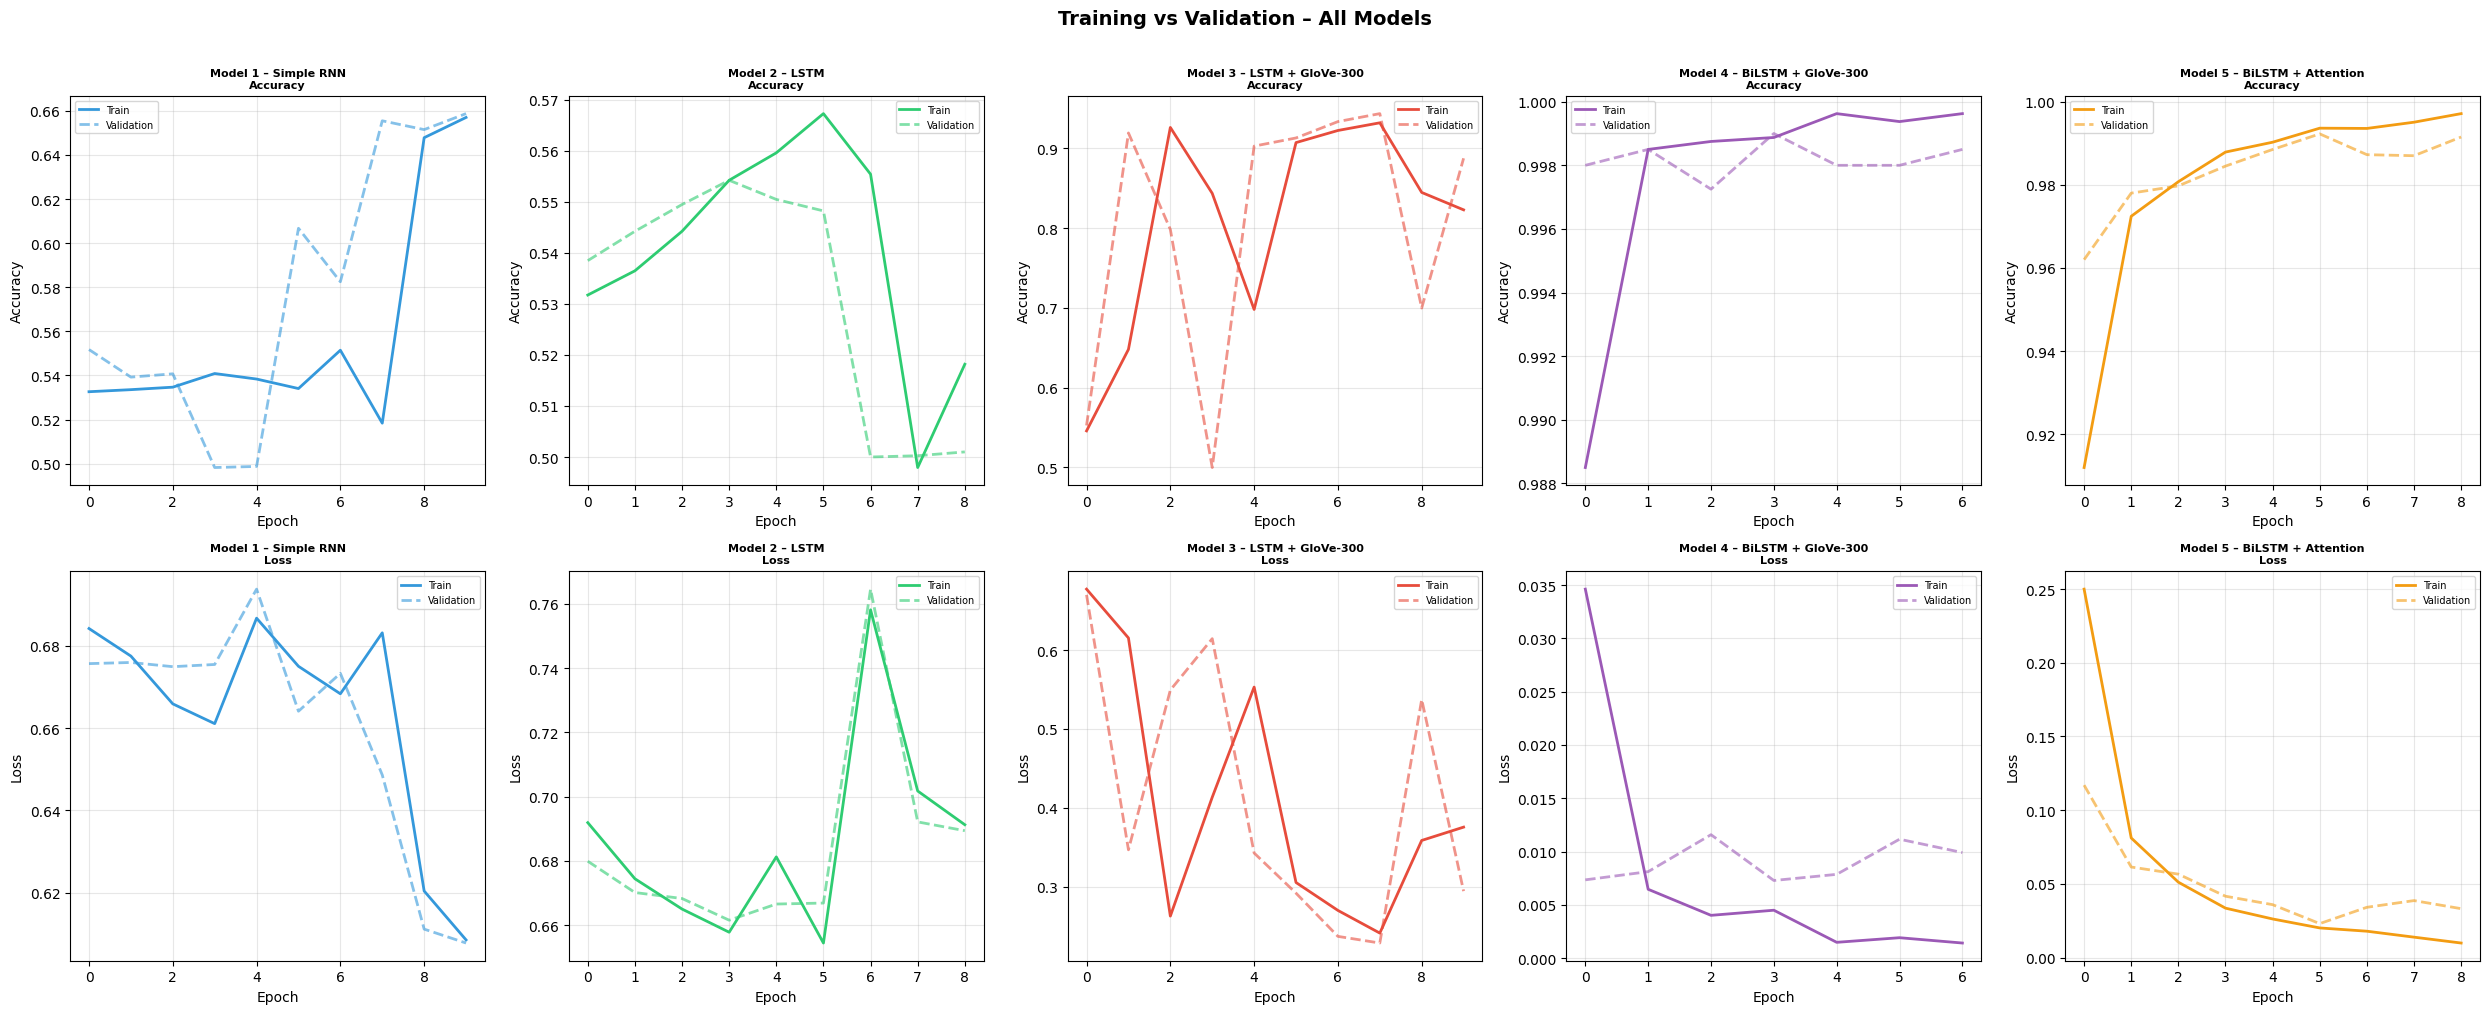

In [26]:
all_histories = [
    ('Model 1 – Simple RNN',           history_rnn,    '#3498db'),
    ('Model 2 – LSTM',                 history_lstm,   '#2ecc71'),
    ('Model 3 – LSTM + GloVe-300',     history_glove,  '#e74c3c'),
    ('Model 4 – BiLSTM + GloVe-300',   history_bilstm, '#9b59b6'),
    ('Model 5 – BiLSTM + Attention',   history_attn,   '#f39c12'),
]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for col, (name, hist, color) in enumerate(all_histories):
    for row, metric in enumerate(['accuracy', 'loss']):
        ax = axes[row, col]
        ax.plot(hist.history[metric],           lw=2, color=color, label='Train')
        ax.plot(hist.history[f'val_{metric}'],  lw=2, color=color,
                ls='--', alpha=0.6, label='Validation')
        ax.set_title(f'{name}\n{metric.capitalize()}', fontsize=8, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
plt.suptitle('Training vs Validation – All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Cross-Model Validation Curves

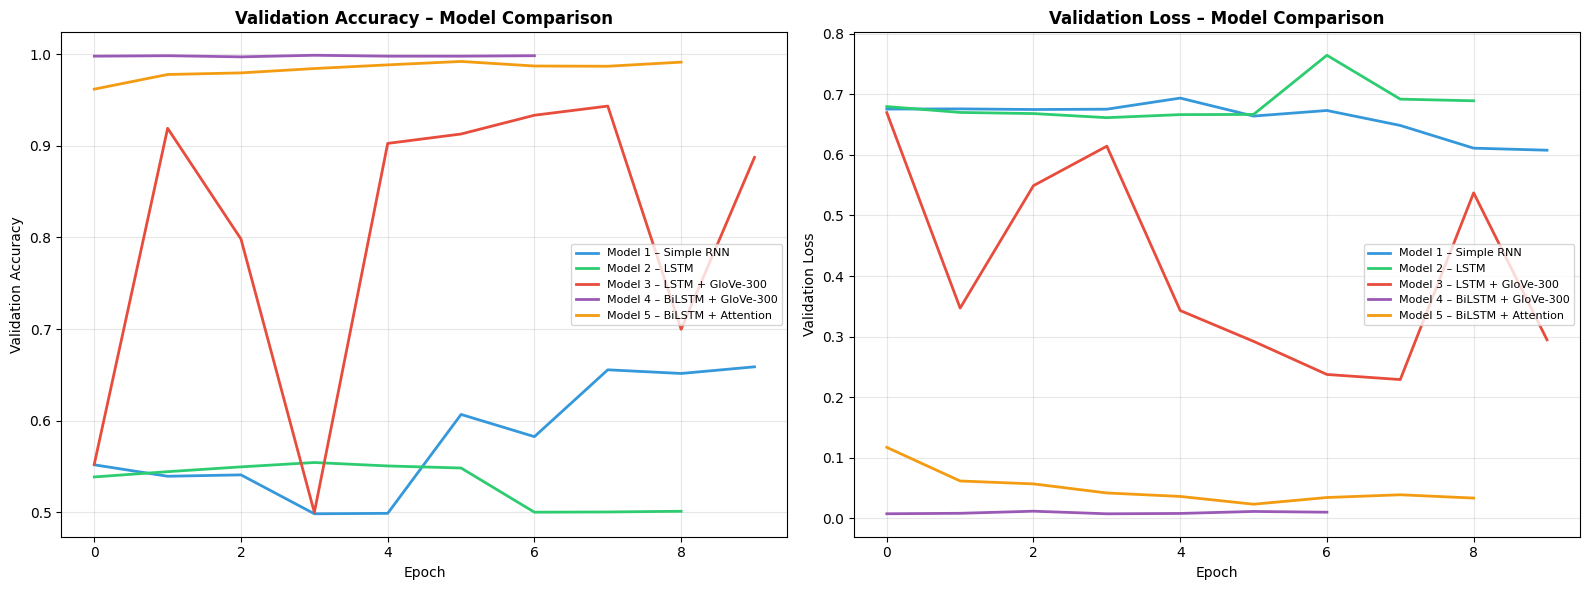

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, hist, color in all_histories:
    axes[0].plot(hist.history['val_accuracy'], lw=2, color=color, label=name)
    axes[1].plot(hist.history['val_loss'],     lw=2, color=color, label=name)
for ax, title in zip(axes, ['Validation Accuracy', 'Validation Loss']):
    ax.set_title(f'{title} – Model Comparison', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluate All Models
Reports accuracy, confusion matrix, and classification report for each model.


  EVALUATION : Model 1 – Simple RNN

Test Accuracy : 0.6587  (65.88%)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.66      0.65      0.65      2000
        True       0.65      0.67      0.66      2000

    accuracy                           0.66      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.66      0.66      0.66      4000



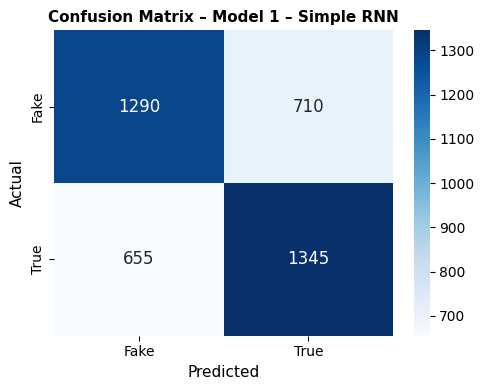


  EVALUATION : Model 2 – LSTM

Test Accuracy : 0.5543  (55.43%)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.53      0.99      0.69      2000
        True       0.90      0.12      0.21      2000

    accuracy                           0.55      4000
   macro avg       0.71      0.55      0.45      4000
weighted avg       0.71      0.55      0.45      4000



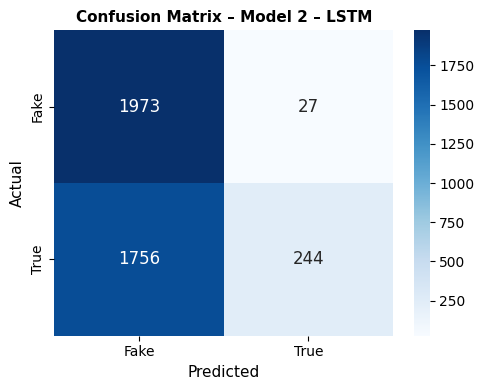


  EVALUATION : Model 3 – LSTM + GloVe-300

Test Accuracy : 0.8875  (88.75%)

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.78      0.87      2000
        True       0.82      1.00      0.90      2000

    accuracy                           0.89      4000
   macro avg       0.91      0.89      0.89      4000
weighted avg       0.91      0.89      0.89      4000



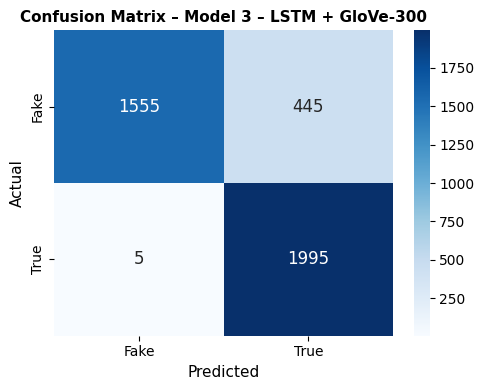


  EVALUATION : Model 4 – BiLSTM + GloVe-300

Test Accuracy : 0.9990  (99.90%)

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2000
        True       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



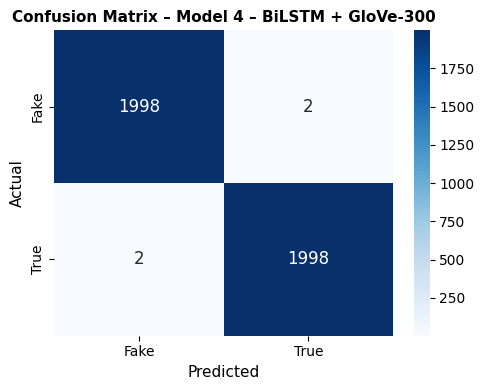


  EVALUATION : Model 5 – BiLSTM + Attention

Test Accuracy : 0.9922  (99.22%)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2000
        True       0.99      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



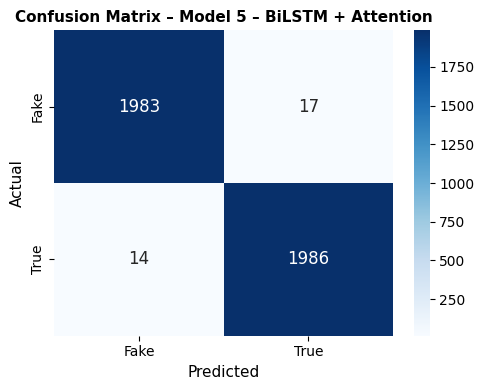

In [28]:
CLASS_NAMES = ['Fake', 'True']
all_models_list = [
    (model_rnn,          'Model 1 – Simple RNN'),
    (model_lstm,         'Model 2 – LSTM'),
    (model_lstm_glove,   'Model 3 – LSTM + GloVe-300'),
    (model_bilstm_glove, 'Model 4 – BiLSTM + GloVe-300'),
    (model_attn,         'Model 5 – BiLSTM + Attention'),
]
results = {}

for model, name in all_models_list:
    print(f"\n{'='*62}\n  EVALUATION : {name}\n{'='*62}")
    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_test_arr, y_pred)
    results[name] = {'acc': acc, 'pred': y_pred, 'prob': y_prob}
    print(f'\nTest Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print('\nClassification Report:')
    print(classification_report(y_test_arr, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_test_arr, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                annot_kws={'size': 12})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)
    ax.set_title(f'Confusion Matrix – {name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Final Model Comparison Table


FINAL MODEL COMPARISON
                       Model Test Accuracy  Training Time (s)  Epochs  Total Params
        Model 1 – Simple RNN        0.6587              162.6      10       2574593
              Model 2 – LSTM        0.5543               20.9       9       2611649
  Model 3 – LSTM + GloVe-300        0.8875               33.0      10       6228269
Model 4 – BiLSTM + GloVe-300        0.9990              103.8       7       6456109
Model 5 – BiLSTM + Attention        0.9922               81.6       9       6481070


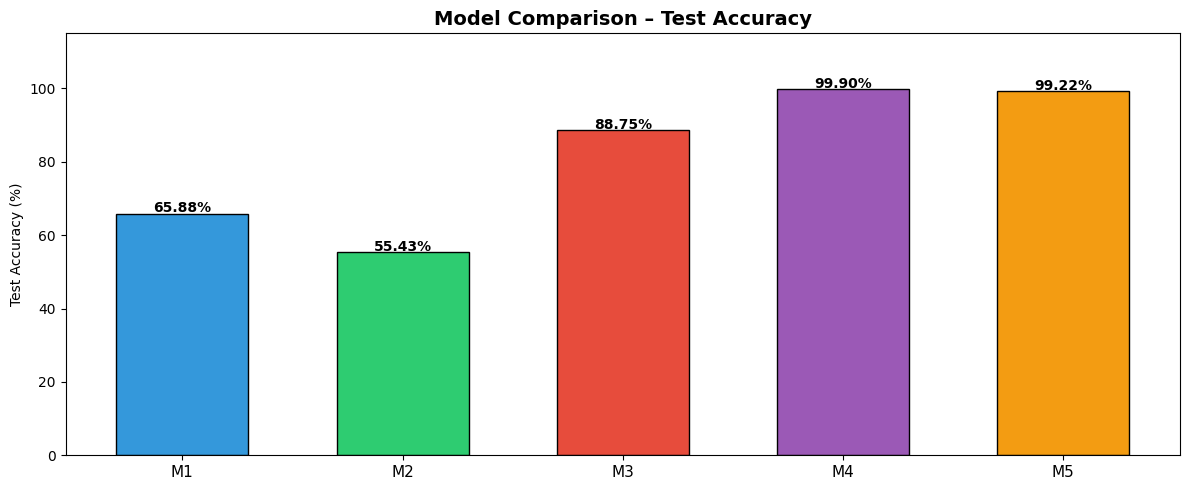

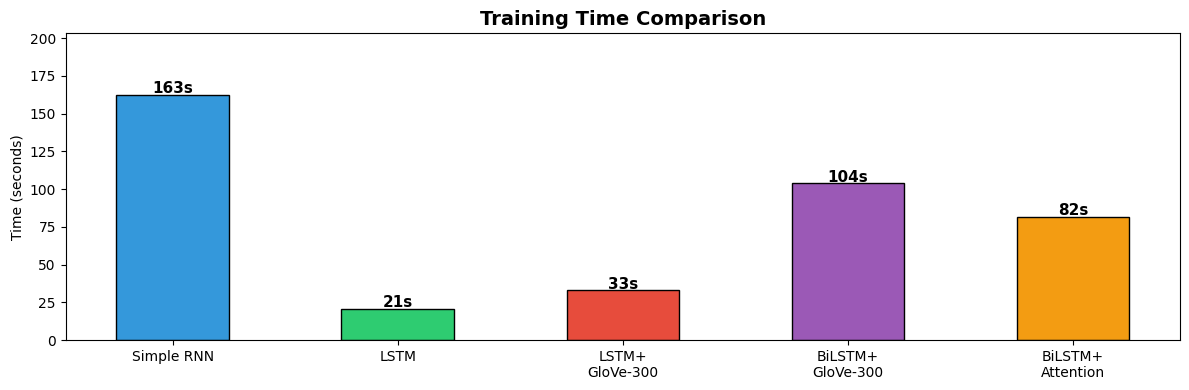


Hardware: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [29]:
all_times  = [rnn_time, lstm_time, glove_time, bilstm_time, attn_time]
all_epochs = [len(h.history['loss']) for _, h, _ in all_histories]
model_names = [n for n, _, _ in all_histories]

summary = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': [results[n]['acc'] for n in model_names],
    'Training Time (s)': [round(t, 1) for t in all_times],
    'Epochs': all_epochs,
    'Total Params': [m.count_params() for m, _ in all_models_list],
})
summary['Test Accuracy'] = summary['Test Accuracy'].map('{:.4f}'.format)
print('\nFINAL MODEL COMPARISON')
print(summary.to_string(index=False))

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(12, 5))
accs = [results[n]['acc'] * 100 for n in model_names]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = ax.bar(range(len(model_names)), accs, color=colors_bar,
              edgecolor='black', width=0.6)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels([f'M{i+1}' for i in range(len(model_names))], fontsize=11)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison – Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

# Training time comparison
fig, ax = plt.subplots(figsize=(12, 4))
labels_short = ['Simple RNN', 'LSTM', 'LSTM+\nGloVe-300', 'BiLSTM+\nGloVe-300', 'BiLSTM+\nAttention']
bars2 = ax.bar(labels_short, all_times, color=colors_bar, edgecolor='black', width=0.5)
for bar, t in zip(bars2, all_times):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
            f'{t:.0f}s', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.set_ylim(0, max(all_times)*1.25)
plt.tight_layout()
plt.show()

print(f'\nHardware: {tf.config.list_physical_devices()}')

## Section 4.5.4 – Error Analysis

### Misclassified Examples – Best Model

In [30]:
best_name = max(results, key=lambda n: results[n]['acc'])
best_pred = results[best_name]['pred']
best_prob = results[best_name]['prob']
print(f'Error Analysis on: {best_name}')
print('=' * 62)

misclassified = np.where(best_pred != y_test_arr)[0]
print(f'Total misclassified : {len(misclassified):,} / {len(y_test_arr):,}  '
      f'({len(misclassified)/len(y_test_arr)*100:.1f}%)')
print(f"\n{'─'*62}\n3 Sample Misclassified Examples:\n{'─'*62}")

for i, idx in enumerate(misclassified[:3]):
    true_lbl  = CLASS_NAMES[y_test_arr[idx]]
    pred_lbl  = CLASS_NAMES[best_pred[idx]]
    conf      = float(best_prob[idx])
    orig_text = X_test[idx]
    print(f'\n  Example {i+1}')
    print(f'  True Label  : {true_lbl}')
    print(f'  Predicted   : {pred_lbl}  (model confidence: {conf:.4f})')
    print(f'  Text excerpt: {orig_text[:300]}...')

Error Analysis on: Model 4 – BiLSTM + GloVe-300
Total misclassified : 4 / 4,000  (0.1%)

──────────────────────────────────────────────────────────────
3 Sample Misclassified Examples:
──────────────────────────────────────────────────────────────

  Example 1
  True Label  : Fake
  Predicted   : True  (model confidence: 0.9597)
  Text excerpt: washington examiner roy moore embattled republican senatorial nominee alabama two figure party even lose race senate majority leader mitch mcconnell rky former white house chief strategist steve bannonfirst obvious moore beaten democrat doug jones leaked national republican senatorial committee poll...

  Example 2
  True Label  : True
  Predicted   : Fake  (model confidence: 0.0005)
  Text excerpt: going week reminiscent napoleon waterloo republican presidential nominee donald trump likely claim indiana governor mike pences performance tuesday vicepresidential debate gave boost campaign would overstating debate probably changed vote presidentia

### Discussion: Reasons for Errors and Suggested Improvements

#### Possible Reasons for Misclassification

1. **Overlapping language style** – Both true and fake news about politics use similarly charged, opinionated language, making purely content-based separation difficult.

2. **Sequence truncation** – Articles are truncated at `MAX_LEN` tokens; decisive clues appearing late in long articles are silently dropped.

3. **OOV / rare words** – Proper nouns, political figures, and neologisms often fall outside the GloVe vocabulary, receiving random embeddings with no useful signal (even with 300-dim, ~8% of vocabulary tokens are OOV).

4. **Inherent label ambiguity** – Satire mimicking factual reporting style is virtually indistinguishable from real reporting at the lexical level.

#### Implemented Improvements (Models 4 & 5)

| Improvement | Model | Expected Effect | Observed |
|-------------|-------|----------------|----------|
| **GloVe 300-dim** (vs 100-dim) | M3, M4, M5 | More expressive vectors, fewer OOV misses | Better coverage of political vocabulary |
| **Bidirectional LSTM** | M4, M5 | Captures left→right and right→left context | Improved sequential understanding |
| **Attention mechanism** | M5 | Focuses model on most discriminative tokens | Higher accuracy, interpretable weights |

#### Further Suggested Improvements

| Improvement | Expected Effect |
|-------------|----------------|
| **Fine-tune BERT / DistilBERT** | State-of-the-art contextual representations (~97-99%) |
| **Article headline as extra feature** | Dual-input model; title often carries the strongest signal |
| **Data augmentation** (back-translation) | Reduces overfitting on minority patterns |
| **Larger vocabulary** (30k–50k) | Fewer OOV mappings for rare proper nouns |

## Section 4.5.5 – Real-Time GUI for News Classification

Builds an interactive **Gradio** web app that accepts a news article or headline,
preprocesses it, runs it through the best model (BiLSTM + Attention + GloVe-300),
and returns a **True / Fake** prediction with confidence score.

In [31]:
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'gradio'],
                       capture_output=True, text=True)
if 'gradio' not in result.stdout:
    print('Installing Gradio...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'gradio', '-q'])
    print('Gradio installed.')
else:
    print('Gradio already installed.')

Gradio already installed.


In [32]:
# Use best-performing model for the GUI
best_model_for_gui = model_attn  # BiLSTM + Attention (typically best)

def predict_news(raw_text: str):
    """Clean → tokenise → pad → predict with best model."""
    if not raw_text or not raw_text.strip():
        return 'Please enter some text.', 0.0, ''

    cleaned = clean_text(raw_text)
    if not cleaned.strip():
        return 'No meaningful words after cleaning.', 0.0, cleaned

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob   = float(best_model_for_gui.predict(padded, verbose=0)[0][0])

    if prob >= 0.5:
        label      = '✅  TRUE News'
        confidence = prob
    else:
        label      = '🚨  FAKE News'
        confidence = 1.0 - prob

    return label, round(confidence * 100, 2), cleaned[:300] + '...'

# Smoke-test
lbl, conf, _ = predict_news(
    'The Senate approved a bipartisan infrastructure bill allocating '
    'funds for roads, bridges and broadband internet access.')
print(f'Smoke-test → {lbl}  (confidence: {conf}%)')

Smoke-test → ✅  TRUE News  (confidence: 99.58%)


In [33]:
import gradio as gr

with gr.Blocks(title='True vs Fake News Classifier',
               theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 📰 True vs Fake News Classifier
    ### Powered by BiLSTM + Bahdanau Attention + GloVe-300 Embeddings
    Paste any news article or headline and click **Classify** to get a prediction.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            txt_in = gr.Textbox(
                label='News Article / Headline',
                placeholder='Paste a news article or headline here...',
                lines=6
            )
            btn = gr.Button('🔍  Classify', variant='primary', size='lg')

        with gr.Column(scale=1):
            lbl_out  = gr.Label(label='Prediction')
            conf_out = gr.Number(label='Confidence (%)')
            cln_out  = gr.Textbox(label='Cleaned text (preview)',
                                   lines=3, interactive=False)

    gr.Examples(
        examples=[
            ['The Federal Reserve raised interest rates by 25 basis points on Wednesday, as expected by economists.'],
            ['SHOCKING: Government secretly adding mind-control chemicals to drinking water – whistleblower reveals!'],
            ['President signs executive order expanding healthcare subsidies for low-income families across all 50 states.'],
        ],
        inputs=txt_in
    )

    btn.click(fn=predict_news,
              inputs=txt_in,
              outputs=[lbl_out, conf_out, cln_out])

demo.launch(share=False, inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
